# Метод главных компонент (PCA)

## Теория

**Метод главных компонент (Principal Component Analysis, PCA)** — один из наиболее широко применяемых методов снижения размерности. Цель PCA — найти новое пространство меньшей размерности, в котором данные сохраняют максимальную дисперсию.

### Основная идея

PCA ищет **ортогональные направления** (главные компоненты), вдоль которых дисперсия данных максимальна. Первая главная компонента — направление наибольшей дисперсии, вторая — ортогональна первой и имеет наибольшую оставшуюся дисперсию, и так далее.

### Шаги алгоритма

1. **Центрирование данных**: вычесть среднее по каждому признаку, чтобы данные имели нулевое среднее.
2. **Вычисление матрицы ковариаций**: отражает совместную изменчивость признаков.
3. **Нахождение собственных векторов и собственных значений** матрицы ковариаций.
4. **Сортировка** собственных векторов по убыванию собственных значений.
5. **Проекция данных** на выбранные главные компоненты.

### Математика

**Матрица ковариаций** (после центрирования):

$$C = \frac{1}{n-1} X^T X$$

**Разложение на собственные векторы** (eigendecomposition):

$$C v_k = \lambda_k v_k$$

где $v_k$ — собственный вектор (главная компонента), $\lambda_k$ — соответствующее собственное значение (дисперсия вдоль данного направления).

**Проекция данных** на $d$ главных компонент:

$$Z = X W_d$$

где $W_d$ — матрица из $d$ ведущих собственных векторов (столбцов).

**Доля объяснённой дисперсии** для $k$-й компоненты:

$$\text{EVR}_k = \frac{\lambda_k}{\sum_i \lambda_i}$$

### Гиперпараметры PCA

| Параметр | Тип | По умолчанию | Описание |
|---|---|---|---|
| `n_components` | int / float / None | None | Число компонент. Если float (0–1) — минимальное число компонент, объясняющих указанную долю дисперсии. None — все компоненты |
| `svd_solver` | str | `'auto'` | Метод вычисления: `'auto'`, `'full'`, `'arpack'`, `'randomized'`. `'full'` — точный SVD; `'randomized'` — быстрый приближённый для больших данных |
| `whiten` | bool | False | Нормировать ли компоненты так, чтобы их дисперсии равнялись единице |

## Датасет

Используется датасет **Breast Cancer Wisconsin** из библиотеки `sklearn`.

### Описание

- **569 объектов**, **30 признаков**, **2 класса**
- Каждый объект — описание клеточного ядра опухоли молочной железы, полученное при биопсии
- Классы: `malignant` (злокачественная, 212 объектов, ~37%) и `benign` (доброкачественная, 357 объектов, ~63%)

### Признаки

Для 10 базовых характеристик клеточных ядер вычисляются 3 статистики: **mean** (среднее), **error** (среднеквадратичная ошибка), **worst** (наихудшее/наибольшее значение). Итого: 10 × 3 = **30 признаков**.

| # | Признак (англ.) | Признак (рус.) |
|---|---|---|
| 1 | radius | радиус |
| 2 | texture | текстура |
| 3 | perimeter | периметр |
| 4 | area | площадь |
| 5 | smoothness | гладкость |
| 6 | compactness | компактность |
| 7 | concavity | вогнутость |
| 8 | concave points | вогнутые точки |
| 9 | symmetry | симметрия |
| 10 | fractal dimension | фрактальная размерность |

Каждый из 10 признаков представлен тремя вариантами:
- `mean` — среднее по клеткам
- `error` (se) — стандартная ошибка
- `worst` — наихудшее (наибольшее) значение

## Используемые библиотеки

В работе используются `numpy`, `pandas`, `matplotlib` и алгоритмы `sklearn` для PCA, стандартизации признаков и оценки качества downstream-классификации


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

np.random.seed(42)

In [3]:
cancer = load_breast_cancer()

X = cancer.data
y = cancer.target

feature_names = cancer.feature_names
target_names = cancer.target_names

print("Размер матрицы признаков X:", X.shape)
print("Размер вектора меток y:    ", y.shape)
print()
print("Признаки:")
for i, name in enumerate(feature_names):
    print(f"  {i+1:2d}. {name}")
print()
print("Классы:", list(target_names))

Размер матрицы признаков X: (569, 30)
Размер вектора меток y:     (569,)

Признаки:
   1. mean radius
   2. mean texture
   3. mean perimeter
   4. mean area
   5. mean smoothness
   6. mean compactness
   7. mean concavity
   8. mean concave points
   9. mean symmetry
  10. mean fractal dimension
  11. radius error
  12. texture error
  13. perimeter error
  14. area error
  15. smoothness error
  16. compactness error
  17. concavity error
  18. concave points error
  19. symmetry error
  20. fractal dimension error
  21. worst radius
  22. worst texture
  23. worst perimeter
  24. worst area
  25. worst smoothness
  26. worst compactness
  27. worst concavity
  28. worst concave points
  29. worst symmetry
  30. worst fractal dimension

Классы: [np.str_('malignant'), np.str_('benign')]


In [4]:
df = pd.DataFrame(X, columns=feature_names)
df["target"] = y

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### Базовые статистики

In [5]:
df.describe().round(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,...,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000
mean,14.127,19.290,91.969,654.889,0.096,0.104,0.089,0.049,0.181,0.063,...,25.677,107.261,880.583,0.132,0.254,0.272,0.115,0.290,0.084,0.627
std,3.524,4.301,24.299,351.914,0.014,0.053,0.080,0.039,0.027,0.007,...,6.146,33.603,569.357,0.023,0.157,0.209,0.066,0.062,0.018,0.484
min,6.981,9.710,43.790,143.500,0.053,0.019,0.000,0.000,0.106,0.050,...,12.020,50.410,185.200,0.071,0.027,0.000,0.000,0.156,0.055,0.000
25%,11.700,16.170,75.170,420.300,0.086,0.065,0.030,0.020,0.162,0.058,...,21.080,84.110,515.300,0.117,0.147,0.114,0.065,0.250,0.071,0.000
50%,13.370,18.840,86.240,551.100,0.096,0.093,0.062,0.034,0.179,0.062,...,25.410,97.660,686.500,0.131,0.212,0.227,0.100,0.282,0.080,1.000
75%,15.780,21.800,104.100,782.700,0.105,0.130,0.131,0.074,0.196,0.066,...,29.720,125.400,1084.000,0.146,0.339,0.383,0.161,0.318,0.092,1.000
max,28.110,39.280,188.500,2501.000,0.163,0.345,0.427,0.201,0.304,0.097,...,49.540,251.200,4254.000,0.223,1.058,1.252,0.291,0.664,0.208,1.000


In [6]:
class_counts = pd.Series(y).value_counts().sort_index()

print("Количество объектов каждого класса:")
for class_id, count in class_counts.items():
    pct = count / len(y) * 100
    print(f"  {target_names[class_id]} ({class_id}): {count} ({pct:.1f}%)")

Количество объектов каждого класса:
  malignant (0): 212 (37.3%)
  benign (1): 357 (62.7%)


### Сравнение классов по средним

In [7]:
mean_features = [col for col in feature_names if 'mean' in col]

df_means = df.groupby("target")[mean_features].mean().round(3)
df_means.index = [target_names[i] for i in df_means.index]

print("Средние значения mean-признаков по классам:")
df_means

Средние значения mean-признаков по классам:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension
malignant,17.463,21.605,115.365,978.376,0.103,0.145,0.161,0.088,0.193,0.063
benign,12.147,17.915,78.075,462.790,0.092,0.080,0.046,0.026,0.174,0.063


## Тепловая карта

Строим тепловую карту корреляций по первым 12 признакам исходного датасета `Breast Cancer Wisconsin`


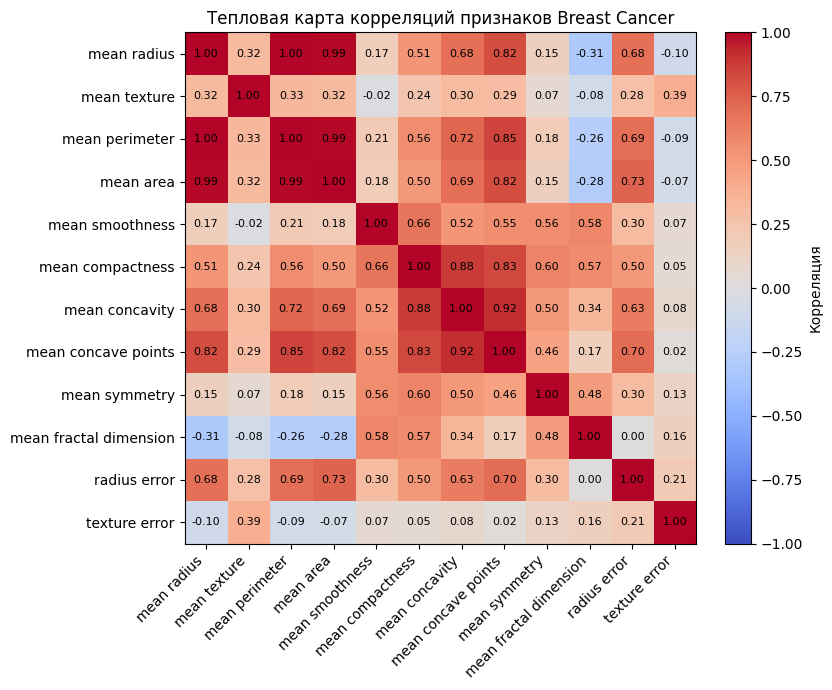

In [8]:
heatmap_features = list(feature_names[:12])

corr_matrix = df[heatmap_features].corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(heatmap_features)))
ax.set_yticks(range(len(heatmap_features)))
ax.set_xticklabels(heatmap_features, rotation=45, ha='right')
ax.set_yticklabels(heatmap_features)
ax.set_title('Тепловая карта корреляций признаков Breast Cancer')

for i in range(len(heatmap_features)):
    for j in range(len(heatmap_features)):
        ax.text(j, i, f"{corr_matrix.values[i, j]:.2f}", ha='center', va='center', color='black', fontsize=8)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Корреляция')
plt.tight_layout()
plt.show()


## Обучение модели

Обучаем PCA на стандартизованных признаках и анализируем долю объяснённой дисперсии по главным компонентам


## Масштабирование

PCA чувствителен к масштабу признаков. Используем `StandardScaler`.

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Форма масштабированных данных:", X_scaled.shape)
print("Среднее по столбцам (должно быть ~0):", np.round(X_scaled.mean(axis=0)[:5], 4))
print("Стд. откл. по столбцам (должно быть ~1):", np.round(X_scaled.std(axis=0)[:5], 4))

Форма масштабированных данных: (569, 30)
Среднее по столбцам (должно быть ~0): [-0. -0. -0. -0.  0.]
Стд. откл. по столбцам (должно быть ~1): [1. 1. 1. 1. 1.]


## PCA: объяснённая дисперсия

Смотрим на долю и накопленную дисперсию по компонентам, чтобы выбрать оптимальное их число.

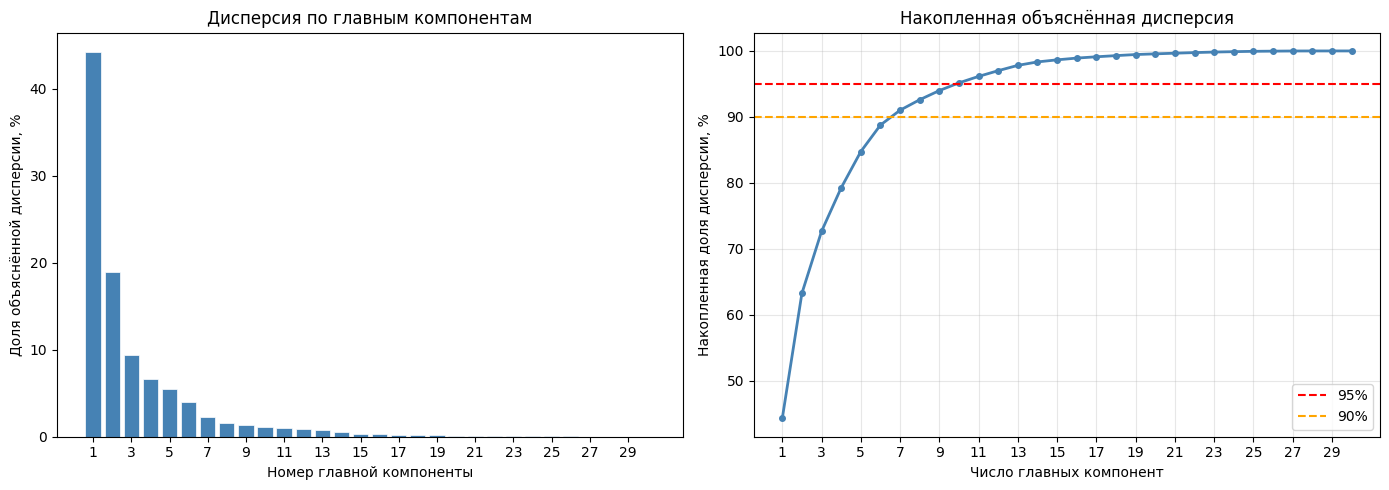

  90% дисперсии объясняют первые 7 компонент
  95% дисперсии объясняют первые 10 компонент
  99% дисперсии объясняют первые 17 компонент

Доля дисперсии первых 5 компонент:
  PC1: 44.27%  (накопленная: 44.27%)
  PC2: 18.97%  (накопленная: 63.24%)
  PC3: 9.39%  (накопленная: 72.64%)
  PC4: 6.60%  (накопленная: 79.24%)
  PC5: 5.50%  (накопленная: 84.73%)


In [10]:
pca_full = PCA()
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(range(1, len(explained_var) + 1), explained_var * 100,
        color='steelblue', edgecolor='white', linewidth=0.5)
ax1.set_xlabel('Номер главной компоненты')
ax1.set_ylabel('Доля объяснённой дисперсии, %')
ax1.set_title('Дисперсия по главным компонентам')
ax1.set_xticks(range(1, len(explained_var) + 1, 2))

ax2.plot(range(1, len(cumulative_var) + 1), cumulative_var * 100,
         marker='o', markersize=4, color='steelblue', linewidth=2)
ax2.axhline(y=95, color='red', linestyle='--', linewidth=1.5, label='95%')
ax2.axhline(y=90, color='orange', linestyle='--', linewidth=1.5, label='90%')
ax2.set_xlabel('Число главных компонент')
ax2.set_ylabel('Накопленная доля дисперсии, %')
ax2.set_title('Накопленная объяснённая дисперсия')
ax2.legend()
ax2.set_xticks(range(1, len(cumulative_var) + 1, 2))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

for threshold in [0.90, 0.95, 0.99]:
    n = np.argmax(cumulative_var >= threshold) + 1
    print(f"  {int(threshold*100)}% дисперсии объясняют первые {n} компонент")

print()
print("Доля дисперсии первых 5 компонент:")
for i in range(5):
    print(f"  PC{i+1}: {explained_var[i]*100:.2f}%  (накопленная: {cumulative_var[i]*100:.2f}%)")

## Визуализация в 2D (2 компоненты)

Проецируем данные на две главные компоненты для визуальной оценки разделимости классов.

## Прогнозы модели

Рассматриваем преобразованные координаты объектов после PCA и оцениваем, насколько информативны полученные компоненты


Форма данных после PCA (2D): (569, 2)
PC1 объясняет: 44.27% дисперсии
PC2 объясняет: 18.97% дисперсии
Суммарно:      63.24% дисперсии


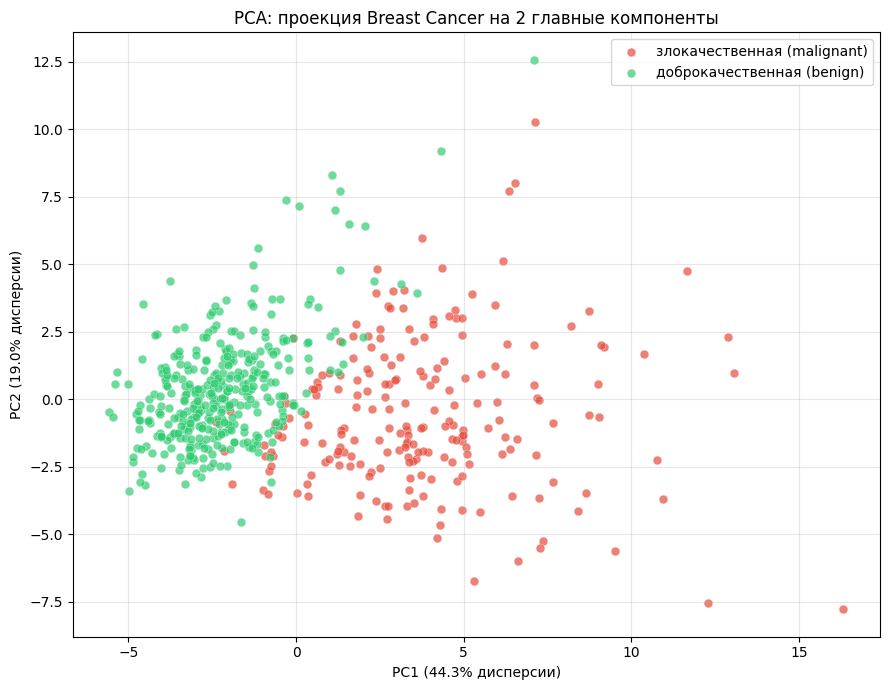

In [11]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print("Форма данных после PCA (2D):", X_pca_2d.shape)
print(f"PC1 объясняет: {pca_2d.explained_variance_ratio_[0]*100:.2f}% дисперсии")
print(f"PC2 объясняет: {pca_2d.explained_variance_ratio_[1]*100:.2f}% дисперсии")
print(f"Суммарно:      {pca_2d.explained_variance_ratio_.sum()*100:.2f}% дисперсии")

colors = ['#e74c3c', '#2ecc71']  # красный — злокачественная, зелёный — доброкачественная
labels = ['злокачественная (malignant)', 'доброкачественная (benign)']

fig, ax = plt.subplots(figsize=(9, 7))

for class_id in [0, 1]:
    mask = y == class_id
    ax.scatter(
        X_pca_2d[mask, 0],
        X_pca_2d[mask, 1],
        c=colors[class_id],
        label=labels[class_id],
        alpha=0.7,
        s=40,
        edgecolors='white',
        linewidths=0.3
    )

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% дисперсии)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% дисперсии)')
ax.set_title('PCA: проекция Breast Cancer на 2 главные компоненты')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Визуализация в 3D (3 компоненты)

Добавляем третью компоненту для более детального рассмотрения структуры данных.

Форма данных после PCA (3D): (569, 3)
PC1 объясняет: 44.27%
PC2 объясняет: 18.97%
PC3 объясняет: 9.39%
Суммарно:      72.64%


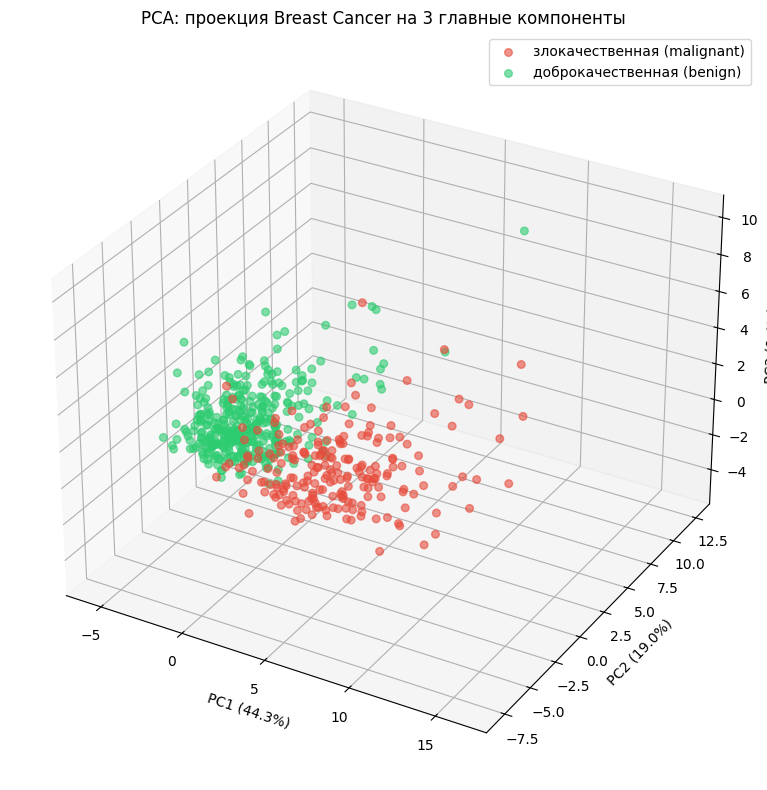

In [12]:
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

print("Форма данных после PCA (3D):", X_pca_3d.shape)
for i in range(3):
    print(f"PC{i+1} объясняет: {pca_3d.explained_variance_ratio_[i]*100:.2f}%")
print(f"Суммарно:      {pca_3d.explained_variance_ratio_.sum()*100:.2f}%")

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

colors = ['#e74c3c', '#2ecc71']
labels = ['злокачественная (malignant)', 'доброкачественная (benign)']

for class_id in [0, 1]:
    mask = y == class_id
    ax.scatter(
        X_pca_3d[mask, 0],
        X_pca_3d[mask, 1],
        X_pca_3d[mask, 2],
        c=colors[class_id],
        label=labels[class_id],
        alpha=0.6,
        s=30
    )

ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)')
ax.set_title('PCA: проекция Breast Cancer на 3 главные компоненты')
ax.legend()

plt.tight_layout()
plt.show()

## Вклад признаков в главные компоненты

Анализируем нагрузки (`components_`) — коэффициенты линейных комбинаций исходных признаков для каждой компоненты.

In [13]:
pca_load = PCA(n_components=2)
pca_load.fit(X_scaled)

loadings = pd.DataFrame(
    pca_load.components_.T,
    index=feature_names,
    columns=['PC1', 'PC2']
)

print("Нагрузки признаков на PC1 и PC2 (отсортировано по |PC1|):")
print(loadings.reindex(loadings['PC1'].abs().sort_values(ascending=False).index).round(4))

Нагрузки признаков на PC1 и PC2 (отсортировано по |PC1|):
                            PC1     PC2
mean concave points      0.2609 -0.0348
mean concavity           0.2584  0.0602
worst concave points     0.2509 -0.0083
mean compactness         0.2393  0.1519
worst perimeter          0.2366 -0.1999
worst concavity          0.2288  0.0980
worst radius             0.2280 -0.2199
mean perimeter           0.2275 -0.2152
worst area               0.2249 -0.2194
mean area                0.2210 -0.2311
mean radius              0.2189 -0.2339
perimeter error          0.2113 -0.0895
worst compactness        0.2101  0.1436
radius error             0.2060 -0.1056
area error               0.2029 -0.1523
concave points error     0.1834  0.1303
compactness error        0.1704  0.2327
concavity error          0.1536  0.1972
mean smoothness          0.1426  0.1861
mean symmetry            0.1382  0.1903
worst fractal dimension  0.1318  0.2753
worst smoothness         0.1280  0.1723
worst symmetry        

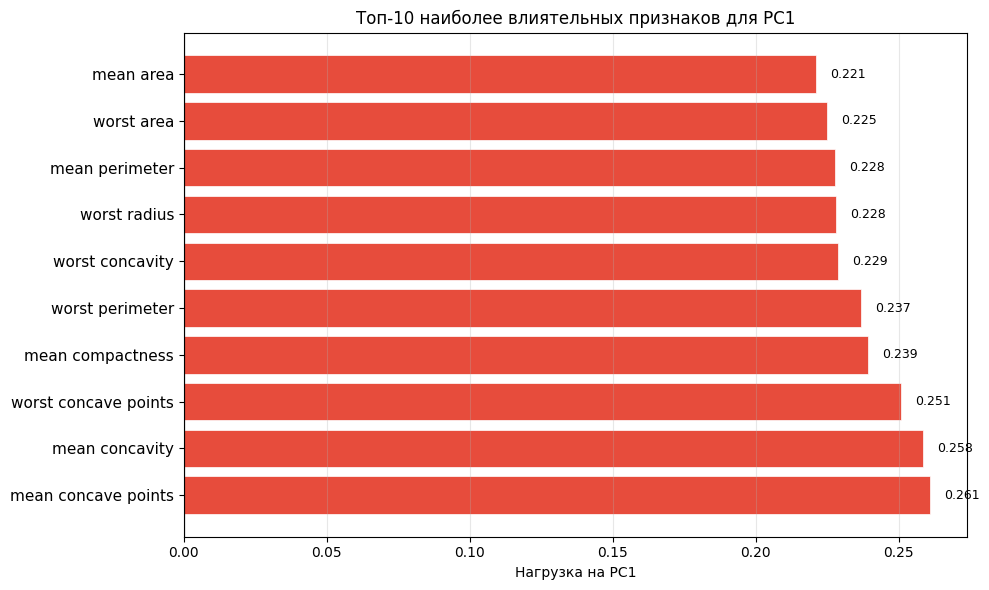


Интерпретация PC1:
  Признаки с большими положительными нагрузками связаны с размером и формой злокачественных клеток.
  Высокие значения PC1 => вероятнее злокачественная опухоль.


In [14]:
pc1_loadings = loadings['PC1'].abs().sort_values(ascending=False)
top10_features = pc1_loadings.head(10).index
top10_values = loadings.loc[top10_features, 'PC1']

fig, ax = plt.subplots(figsize=(10, 6))

bar_colors = ['#e74c3c' if v > 0 else '#3498db' for v in top10_values]
bars = ax.barh(range(len(top10_features)), top10_values.values,
               color=bar_colors, edgecolor='white', linewidth=0.5)

ax.set_yticks(range(len(top10_features)))
ax.set_yticklabels(top10_features, fontsize=11)
ax.set_xlabel('Нагрузка на PC1')
ax.set_title('Топ-10 наиболее влиятельных признаков для PC1')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.grid(True, axis='x', alpha=0.3)

for i, (val, bar) in enumerate(zip(top10_values.values, bars)):
    ax.text(val + (0.005 if val >= 0 else -0.005),
            i, f'{val:.3f}',
            va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

print("\nИнтерпретация PC1:")
print("  Признаки с большими положительными нагрузками связаны с размером и формой злокачественных клеток.")
print("  Высокие значения PC1 => вероятнее злокачественная опухоль.")

## PCA + классификация

Сравниваем точность логистической регрессии на исходных признаках и на данных, сжатых PCA до разного числа компонент.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler_cls = StandardScaler()
X_train_scaled = scaler_cls.fit_transform(X_train)
X_test_scaled = scaler_cls.transform(X_test)

print("Размер обучающей выборки:", X_train_scaled.shape)
print("Размер тестовой выборки: ", X_test_scaled.shape)

Размер обучающей выборки: (455, 30)
Размер тестовой выборки:  (114, 30)


In [16]:
clf_full = LogisticRegression(max_iter=5000, random_state=42)
clf_full.fit(X_train_scaled, y_train)
acc_full = accuracy_score(y_test, clf_full.predict(X_test_scaled))

print(f"Точность на 30 признаках (без PCA): {acc_full*100:.2f}%")

n_components_list = [2, 3, 5, 7, 10, 15, 20, 25, 30]
accuracies = []

for n in n_components_list:
    pca_cls = PCA(n_components=n)
    X_train_pca = pca_cls.fit_transform(X_train_scaled)
    X_test_pca = pca_cls.transform(X_test_scaled)

    clf_pca = LogisticRegression(max_iter=5000, random_state=42)
    clf_pca.fit(X_train_pca, y_train)
    acc = accuracy_score(y_test, clf_pca.predict(X_test_pca))
    accuracies.append(acc)

    var_sum = pca_cls.explained_variance_ratio_.sum()
    print(f"  n_components={n:2d}: точность {acc*100:.2f}%  (объяснённая дисперсия: {var_sum*100:.1f}%)")

print(f"\nЛучший результат с PCA: {max(accuracies)*100:.2f}% при n={n_components_list[np.argmax(accuracies)]} компонентах")

Точность на 30 признаках (без PCA): 98.25%
  n_components= 2: точность 94.74%  (объяснённая дисперсия: 63.4%)
  n_components= 3: точность 92.11%  (объяснённая дисперсия: 72.9%)
  n_components= 5: точность 95.61%  (объяснённая дисперсия: 85.1%)
  n_components= 7: точность 94.74%  (объяснённая дисперсия: 91.3%)
  n_components=10: точность 97.37%  (объяснённая дисперсия: 95.3%)
  n_components=15: точность 96.49%  (объяснённая дисперсия: 98.7%)
  n_components=20: точность 98.25%  (объяснённая дисперсия: 99.6%)
  n_components=25: точность 98.25%  (объяснённая дисперсия: 99.9%)


  n_components=30: точность 98.25%  (объяснённая дисперсия: 100.0%)

Лучший результат с PCA: 98.25% при n=20 компонентах


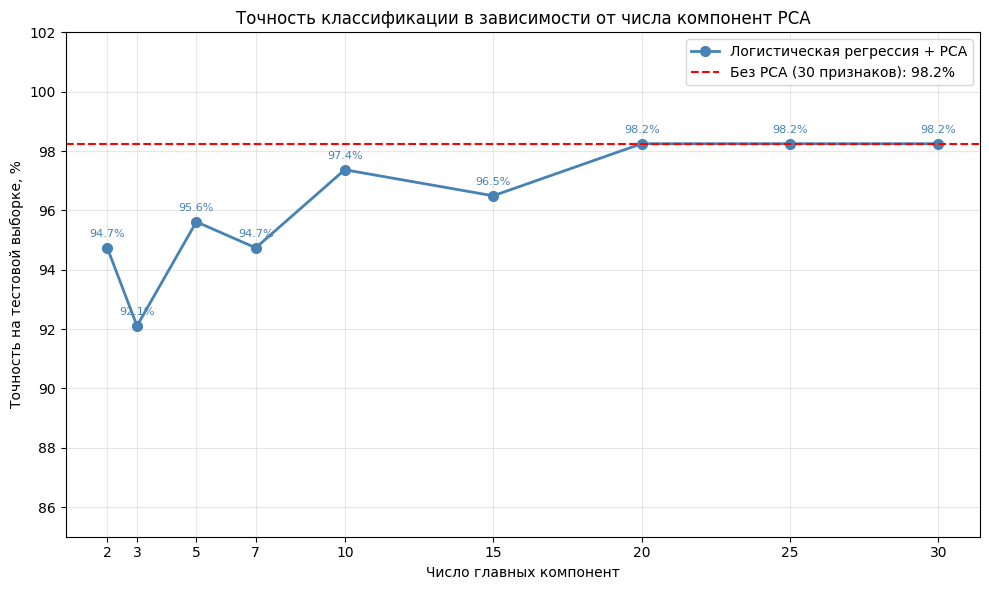

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(n_components_list, [a * 100 for a in accuracies],
        marker='o', markersize=7, color='steelblue', linewidth=2,
        label='Логистическая регрессия + PCA')

ax.axhline(y=acc_full * 100, color='red', linestyle='--', linewidth=1.5,
           label=f'Без PCA (30 признаков): {acc_full*100:.1f}%')

ax.set_xlabel('Число главных компонент')
ax.set_ylabel('Точность на тестовой выборке, %')
ax.set_title('Точность классификации в зависимости от числа компонент PCA')
ax.set_xticks(n_components_list)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([85, 102])

for n, acc in zip(n_components_list, accuracies):
    ax.annotate(f'{acc*100:.1f}%', xy=(n, acc*100),
                xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=8, color='steelblue')

plt.tight_layout()
plt.show()

## Влияние масштабирования на PCA

Сравниваем PCA без стандартизации и с `StandardScaler` — без масштабирования первая компонента захватывает почти всю дисперсию за счёт признаков с большим диапазоном.

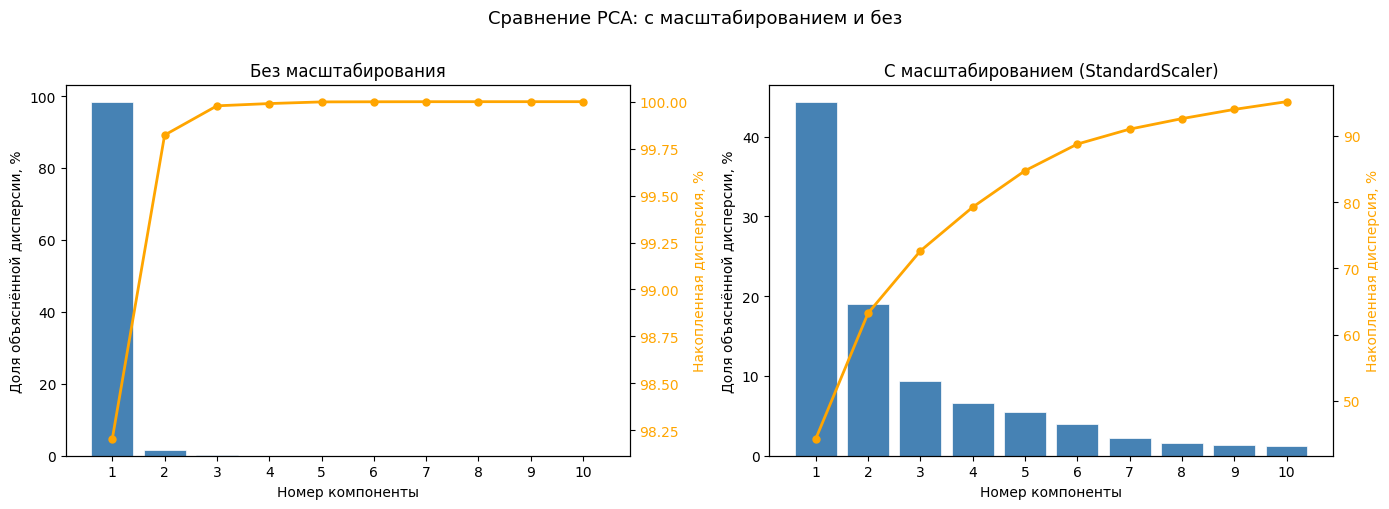

Накопленная дисперсия (10 компонент):
  Без масштабирования:  100.00%
  С масштабированием:   95.16%

PC1 без масштабирования объясняет: 98.20% (доминирует один признак с большой дисперсией)
PC1 с масштабированием объясняет:  44.27% (дисперсия распределена по признакам равномернее)


In [18]:
pca_no_scale = PCA(n_components=10)
pca_no_scale.fit(X)  # сырые данные без StandardScaler

pca_with_scale = PCA(n_components=10)
pca_with_scale.fit(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pca_obj, title in zip(
    axes,
    [pca_no_scale, pca_with_scale],
    ['Без масштабирования', 'С масштабированием (StandardScaler)']
):
    cumulative = np.cumsum(pca_obj.explained_variance_ratio_)
    ax.bar(range(1, 11), pca_obj.explained_variance_ratio_ * 100,
           color='steelblue', edgecolor='white', linewidth=0.5, label='Доля')
    ax_twin = ax.twinx()
    ax_twin.plot(range(1, 11), cumulative * 100,
                 marker='o', color='orange', linewidth=2, markersize=5, label='Накопленная')
    ax_twin.set_ylabel('Накопленная дисперсия, %', color='orange')
    ax_twin.tick_params(axis='y', labelcolor='orange')
    ax.set_xlabel('Номер компоненты')
    ax.set_ylabel('Доля объяснённой дисперсии, %')
    ax.set_title(title)
    ax.set_xticks(range(1, 11))

plt.suptitle('Сравнение PCA: с масштабированием и без', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("Накопленная дисперсия (10 компонент):")
print(f"  Без масштабирования:  {pca_no_scale.explained_variance_ratio_.sum()*100:.2f}%")
print(f"  С масштабированием:   {pca_with_scale.explained_variance_ratio_.sum()*100:.2f}%")

print()
print("PC1 без масштабирования объясняет:",
      f"{pca_no_scale.explained_variance_ratio_[0]*100:.2f}% (доминирует один признак с большой дисперсией)")
print("PC1 с масштабированием объясняет: ",
      f"{pca_with_scale.explained_variance_ratio_[0]*100:.2f}% (дисперсия распределена по признакам равномернее)")

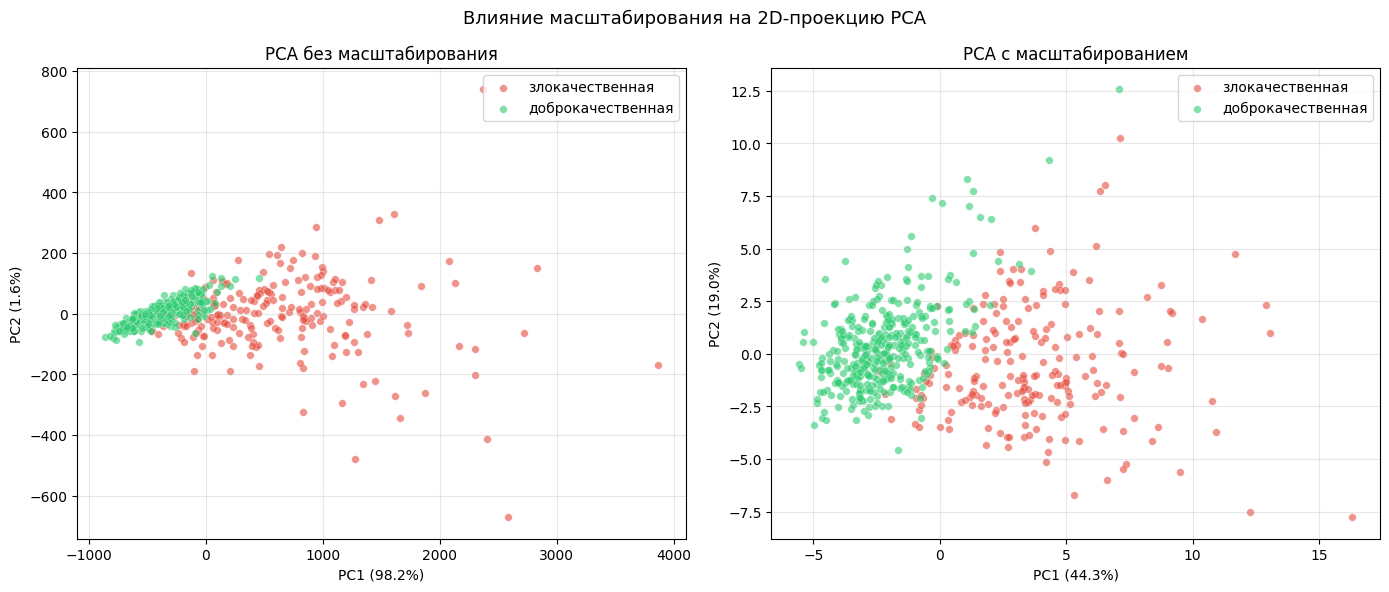

In [19]:
pca_2d_no_scale = PCA(n_components=2)
X_2d_no_scale = pca_2d_no_scale.fit_transform(X)

pca_2d_scaled = PCA(n_components=2)
X_2d_scaled = pca_2d_scaled.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#e74c3c', '#2ecc71']
labels = ['злокачественная', 'доброкачественная']

for ax, X_2d, pca_obj, title in zip(
    axes,
    [X_2d_no_scale, X_2d_scaled],
    [pca_2d_no_scale, pca_2d_scaled],
    ['PCA без масштабирования', 'PCA с масштабированием']
):
    for class_id in [0, 1]:
        mask = y == class_id
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=colors[class_id], label=labels[class_id],
                   alpha=0.6, s=30, edgecolors='white', linewidths=0.3)
    ev = pca_obj.explained_variance_ratio_
    ax.set_xlabel(f'PC1 ({ev[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({ev[1]*100:.1f}%)')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Влияние масштабирования на 2D-проекцию PCA', fontsize=13)
plt.tight_layout()
plt.show()